In [ ]:
 # Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
import joblib



In [ ]:
data = pd.read_csv('psychometric.csv')

In [ ]:
data.shape

(1000, 7)

In [ ]:
data.head()

,employee_name,user_id,O,C,E,A,N
0,Calvin Edan Love,CEL0561,40,39,36,19,40
1,Christine Reagan Deleon,CRD0624,26,22,17,39,32
2,Jade Felicia Caldwell,JFC0557,22,16,23,40,33
3,Aquila Stewart Dejesus,ASD0577,40,48,36,14,37
4,Micah Abdul Rojas,MAR0955,36,44,23,44,25


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   employee_name  1000 non-null   object
 1   user_id        1000 non-null   object
 2   O              1000 non-null   int64 
 3   C              1000 non-null   int64 
 4   E              1000 non-null   int64 
 5   A              1000 non-null   int64 
 6   N              1000 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 54.8+ KB


In [ ]:
data.describe()

,O,C,E,A,N
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,33.173000,30.653000,29.19700,28.821000,29.608000
std,10.642007,11.291505,10.95647,11.170844,4.938494
min,10.000000,10.000000,10.00000,10.000000,14.000000
25%,23.000000,20.000000,19.00000,19.000000,26.000000
50%,36.000000,33.000000,28.00000,27.000000,29.000000
75%,42.000000,40.000000,39.00000,39.000000,33.000000
max,50.000000,50.000000,50.00000,50.000000,49.000000


In [ ]:
data.drop(['employee_name', 'user_id'], axis=1, inplace=True)

In [ ]:
data['Threat'] = ((data['N'] > 35) & (data['C'] < 25) & (data['A'] < 25)).astype(int)

C:\Users\onlin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\onlin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\onlin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\onlin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

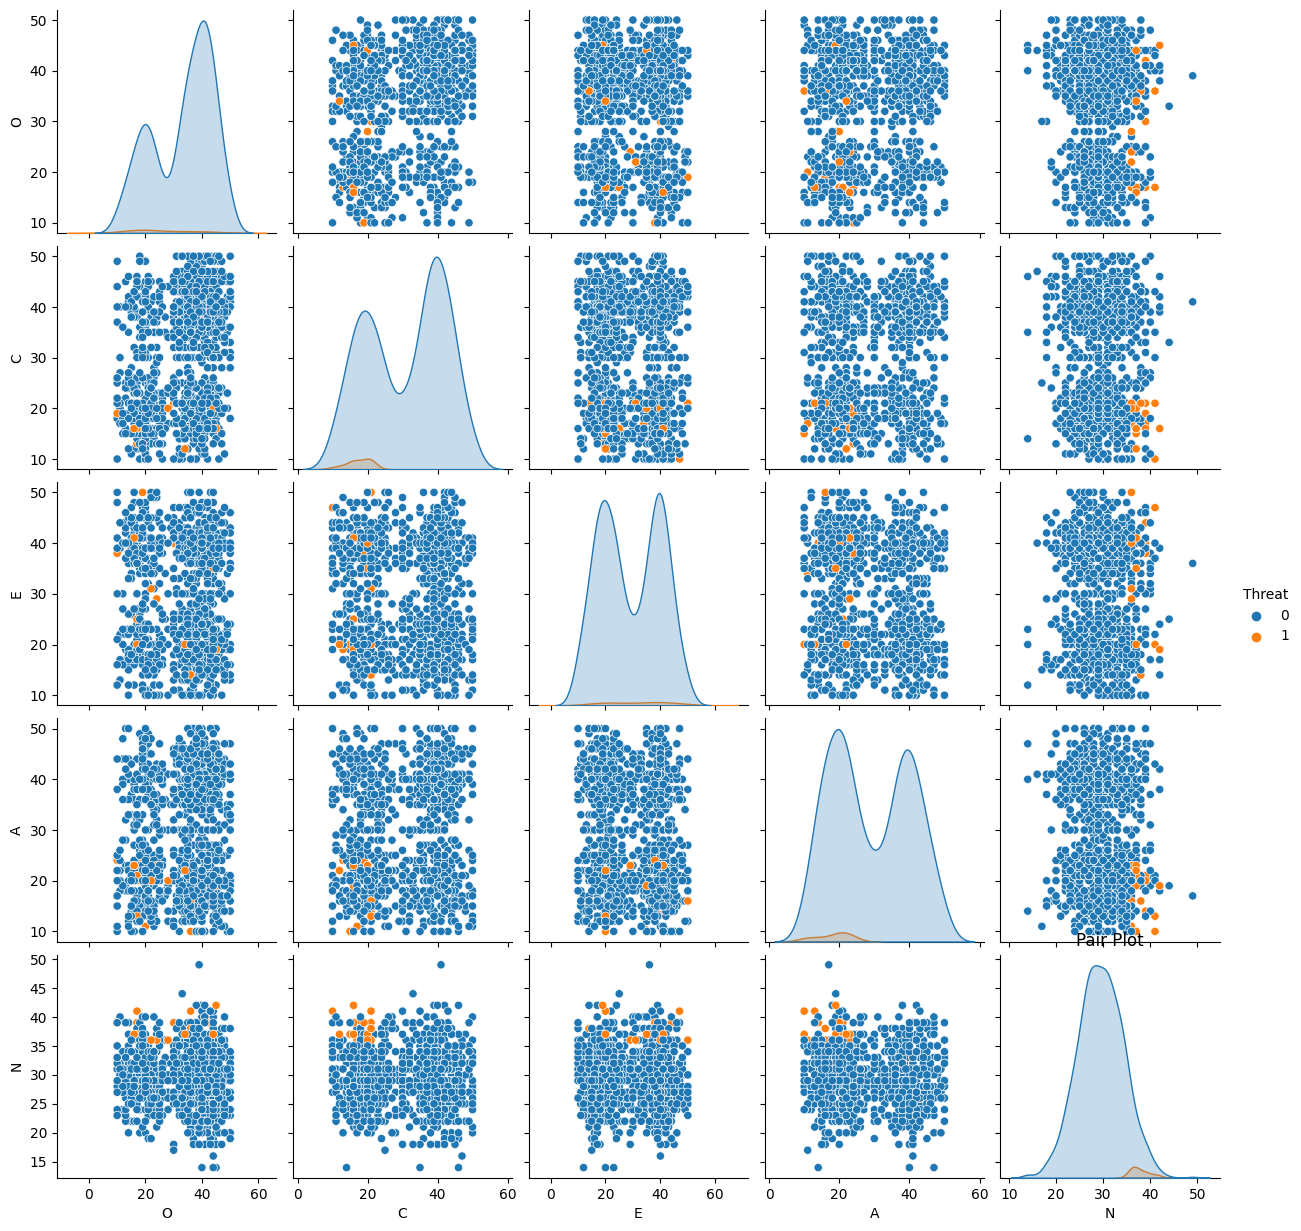

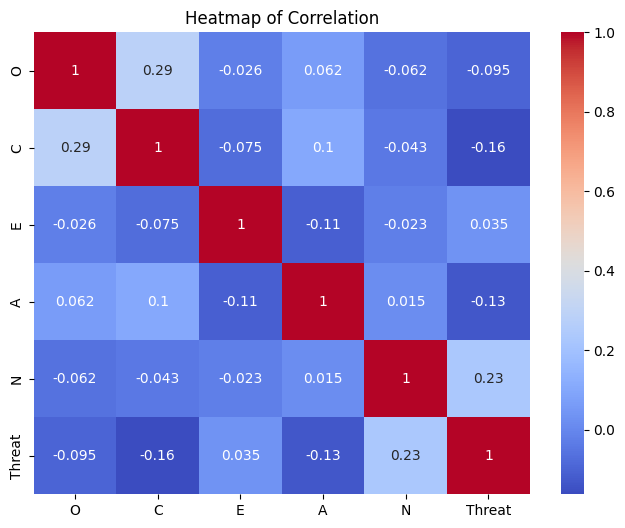

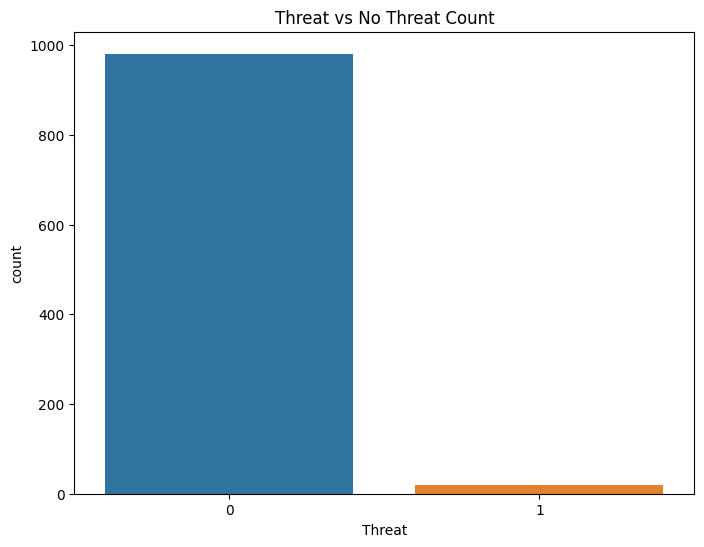

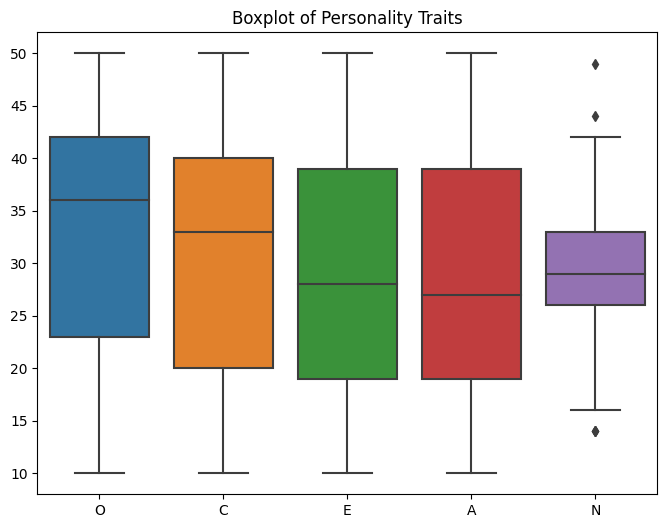

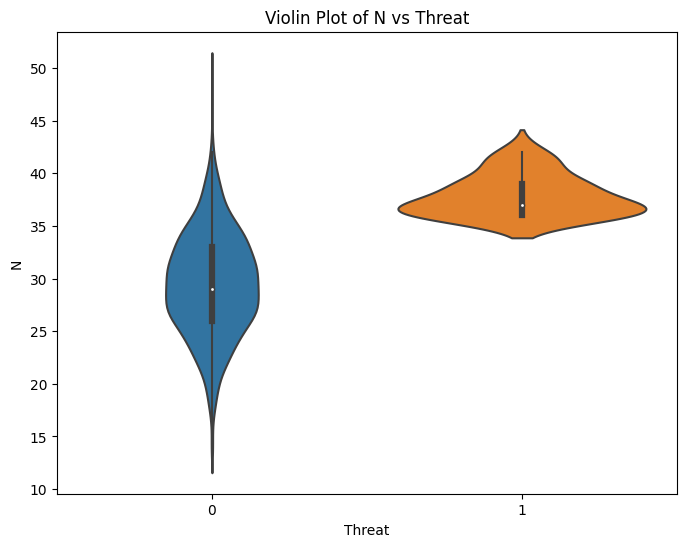

In [ ]:

sns.pairplot(data, hue='Threat')
plt.title("Pair Plot")
plt.savefig('pairplot.png')

plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap of Correlation")
plt.savefig('heatmap.png')

plt.figure(figsize=(8, 6))
sns.countplot(x='Threat', data=data)
plt.title("Threat vs No Threat Count")
plt.savefig('threat_count.png')

plt.figure(figsize=(8, 6))
sns.boxplot(data[['O', 'C', 'E', 'A', 'N']])
plt.title("Boxplot of Personality Traits")
plt.savefig('boxplot.png')

plt.figure(figsize=(8, 6))
sns.violinplot(x='Threat', y='N', data=data)
plt.title("Violin Plot of N vs Threat")
plt.savefig('violinplot.png')

In [ ]:
X = data[['O', 'C', 'E', 'A', 'N']]
y = data['Threat']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# RandomForestClassifier
# Train Decision Tree
# Train XGBoost
# Train CNN Model

In [ ]:

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
joblib.dump(rf_model, 'random_forest.pkl')


dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
joblib.dump(dt_model, 'decision_tree.pkl')


xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
joblib.dump(xgb_model, 'xgboost.pkl')


cnn_model = Sequential()
cnn_model.add(Dense(128, input_dim=5, activation='relu'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))
cnn_model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

history = cnn_model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.2, verbose=1)
cnn_acc = cnn_model.evaluate(X_test, y_test)[1]

cnn_model.save('cnn_model.h5')

print(f"Random Forest Accuracy: {rf_acc}")
print(f"Decision Tree Accuracy: {dt_acc}")
print(f"XGBoost Accuracy: {xgb_acc}")
print(f"CNN Accuracy: {cnn_acc}")




In [ ]:

best_model = max([(rf_acc, 'random_forest.pkl'),
                  (dt_acc, 'decision_tree.pkl'),
                  (xgb_acc, 'xgboost.pkl'),
                  (cnn_acc, 'cnn_model.h5')])

print(f"Best Model: {best_model[1]}")